# Othello / Reversi — DQN Agent Training & Tournament

This notebook trains **four variants** of DQN agents on Othello (5×5) and
then has them play a tournament against each other and rule-based agents.

| Agent | `use_per` | `heuristic_weight` | Description |
|---|---|---|---|
| **DQN** | ✗ | 0.0 | Classic Double-DQN |
| **Guided DQN** | ✗ | 0.2 | HDQN with heuristic |
| **PER DQN** | ✓ | 0.0 | Prioritized Experience Replay |
| **Guided PER** | ✓ | 0.2 | HDQN + PER |

**Self-play** is part of each agent's training — every 500 episodes
a snapshot of the agent is frozen and added to the opponent pool.

### Notebook Structure
1. Environment setup and imports  
2. Training configuration  
3. Training all four agents (+ live graphs)  
4. Individual evaluation vs. rule-based agents  
5. Round-robin tournament (DQN agents against each other)  
6. Results summary and comparative graphs

## 1 — Environment Setup

In [1]:
# ── Dependencies ───────────────────────────────────────────────────
# If running on Google Colab or a fresh venv:
# !pip install torch numpy matplotlib tqdm --quiet

In [2]:
import sys, os, copy, random, warnings
warnings.filterwarnings("ignore")

# Add project root directory to sys.path so imports work.
# Adjust the path according to your directory!
PROJECT_ROOT = "."          # or e.g. "/content/drive/MyDrive/othello"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
from IPython.display import display, clear_output

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.12.1+cu130 | device: cuda


In [3]:
# ── Project Imports ───────────────────────────────────────────
from environment import OthelloEnv
from evaluation  import evaluate_fair, play_game
from agent       import DQNAgent

from agents.random_agent    import RandomAgent
from agents.greedy_agent    import GreedyAgent
from agents.heuristic_agent import HeuristicAgent
from agents.minimax_agent   import MinimaxAgent
from train_multi_agent import train_multi_agent

OPPONENT_CLASSES = {
    "random":    RandomAgent,
    "greedy":    GreedyAgent,
    "heuristic": HeuristicAgent,
    "minimax":   MinimaxAgent,
}
print("Imports OK")

Imports OK


## 2 — Training Configuration

All parameters in one place — adjust as needed.

In [4]:
# ── Global Configuration ───────────────────────────────────────────
BOARD_SIZE    = 6
SEED          = 42
MODELS_DIR    = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── Training Hyperparameters (shared) ───────────────────────────
TRAIN_CFG = dict(
    board_size         = BOARD_SIZE,
    num_episodes       = 50_000,     # ← episodes per agent
    epsilon_start      = 1.0,
    epsilon_end        = 0.05,
    epsilon_decay      = 0.9999,     # reaches 0.05 by ~30k episodes (was 0.99999 = never decays)
    opponent_type      = "mix",     # curriculum mix including self-play
    learning_rate      = 3e-4,      # ↓ from 1e-3 (more stable)
    gamma              = 0.99,
    batch_size         = 64,
    buffer_capacity    = 50_000,
    target_update_freq = 500,
    learning_starts    = 1_000,
    self_play_update_freq = 500,    # freeze snapshot every N episodes
    eval_every         = 1000,       # evaluation during training
    eval_games         = 200,       # ↑ from 60 (less noisy eval)
    print_every        = 9_999_999,     # suppress text output (we have graphs)
    save_every         = 1_000,
    seed               = SEED,
    # --- shaped reward weights ---
    reward_final       = 1.0,
    reward_disc_scale  = 0.01,      # small bonus for disc-diff improvement
    reward_corner      = 0.25,      # bonus for capturing a corner
    reward_mobility    = 0.02,      # small bonus for mobility advantage
)

# ── Agent Definitions ─────────────────────────────────────────────
# heuristic_weight anneals from heuristic_weight → heuristic_weight_end
# over heuristic_decay_episodes, so the network learns its own strategy.
AGENT_CONFIGS = {
    # "DQN": dict(
    #     use_per=False, heuristic_weight=0.0,
    #     model_path=f"{MODELS_DIR}/dqn.pth",
    # ),
    "Guided DQN": dict(
        use_per=False, heuristic_weight=0.1,
        heuristic_weight_end=0.0, heuristic_decay_episodes=30_000,
        model_path=f"{MODELS_DIR}/guided_dqn_50k.pth",
    ),
    # "PER DQN": dict(
    #     use_per=True, heuristic_weight=0.0,
    #     per_alpha=0.6, per_beta_start=0.4, per_beta_frames=100_000,
    #     model_path=f"{MODELS_DIR}/per_dqn.pth",
    # ),
    # "Guided PER": dict(
    #     use_per=True, heuristic_weight=0.1,
    #     heuristic_weight_end=0.0,
    #     heuristic_decay_episodes=30_000,
    #     per_alpha=0.6, per_beta_start=0.4, per_beta_frames=100_000,
    #     model_path=f"{MODELS_DIR}/guided_per_dqn.pth",
    # ),
}

print("Configuration:")
for name, cfg in AGENT_CONFIGS.items():
    hw  = cfg.get("heuristic_weight", 0.0)
    per = cfg.get("use_per", False)
    print(f"  {name:<15} use_per={str(per):<5}  heuristic_weight={hw}")


Configuration:
  Guided DQN      use_per=False  heuristic_weight=0.1


## 3 — Training Agents

Each agent is trained independently using **curriculum mixing**:
- **Phase 1 (0–30 %)**: random / greedy opponents  
- **Phase 2 (30–70 %)**: heuristic and minimax are added  
- **Phase 3 (70–100 %)**: self-play dominates (snapshot frozen every 500 episodes)

Graphs are updated live for each agent.

In [5]:
# ── Helper Functions for Training ───────────────────────────────

def compute_final_reward(winner: int, agent_player: int) -> float:
    if winner == agent_player: return  1.0
    if winner == 0:            return  0.0
    return -1.0


def shaped_step_reward(env, agent_player: int, cfg: dict) -> float:
    """
    Small intermediate reward signal to densify the sparse Othello reward.
    Combines disc-difference, corner ownership, and mobility advantage.
    All terms are scaled to stay small relative to the final ±1 reward.
    """
    disc = env.get_disc_difference(agent_player)
    corner = env.count_corners(agent_player) - env.count_corners(-agent_player)
    mob = env.count_legal_actions(agent_player) - env.count_legal_actions(-agent_player)

    return (
        cfg.get("reward_disc_scale", 0.0)  * disc
      + cfg.get("reward_corner", 0.0)     * corner
      + cfg.get("reward_mobility", 0.0)   * mob
    )


def choose_opponent_curriculum(episode: int, num_episodes: int) -> str:
    """Three-phase curriculum opponent selection (smoother transitions)."""
    p = episode / num_episodes
    names = ["random", "greedy", "heuristic", "minimax", "self-play"]
    if p < 0.30:
        weights = [0.40, 0.30, 0.15, 0.10, 0.05]
    elif p < 0.70:
        weights = [0.15, 0.15, 0.25, 0.20, 0.25]
    else:
        weights = [0.05, 0.05, 0.15, 0.25, 0.50]
    return random.choices(names, weights=weights, k=1)[0]


def epsilon_floor(base_eps: float, opp_type: str) -> float:
    floors = {"greedy": 0.15, "heuristic": 0.15, "minimax": 0.20}
    return max(base_eps, floors.get(opp_type, 0.0))


def moving_average(arr, window=100):
    if len(arr) < window:
        return np.array(arr)
    return np.convolve(arr, np.ones(window)/window, mode="valid")


In [6]:
def train_agent_with_plot(agent_name: str, agent_cfg: dict, train_cfg: dict):
    """
    Trains one agent and displays live graphs.
    Returns (agent, history_dict).
    """
    set_seed(train_cfg["seed"])

    board_size          = train_cfg["board_size"]
    num_episodes        = train_cfg["num_episodes"]
    eps_start           = train_cfg["epsilon_start"]
    eps_end             = train_cfg["epsilon_end"]
    eps_decay           = train_cfg["epsilon_decay"]
    self_play_upd_freq  = train_cfg["self_play_update_freq"]
    eval_every          = train_cfg["eval_every"]
    eval_games          = train_cfg.get("eval_games", 60)
    save_every          = train_cfg["save_every"]
    model_path          = agent_cfg["model_path"]

    # ── Agent Creation ──────────────────────────────────────────
    agent = DQNAgent(
        board_size         = board_size,
        learning_rate      = train_cfg["learning_rate"],
        gamma              = train_cfg["gamma"],
        batch_size         = train_cfg["batch_size"],
        buffer_capacity    = train_cfg["buffer_capacity"],
        target_update_freq = train_cfg["target_update_freq"],
        learning_starts    = train_cfg["learning_starts"],
        use_per            = agent_cfg.get("use_per",            False),
        heuristic_weight   = agent_cfg.get("heuristic_weight",   0.0),
        heuristic_weight_end    = agent_cfg.get("heuristic_weight_end",    0.0),
        heuristic_decay_episodes = agent_cfg.get("heuristic_decay_episodes", num_episodes),
        per_alpha          = agent_cfg.get("per_alpha",          0.6),
        per_beta_start     = agent_cfg.get("per_beta_start",     0.4),
        per_beta_frames    = agent_cfg.get("per_beta_frames",    100_000),
    )

    # Self-play snapshot (frozen copy)
    self_play_snapshot = copy.deepcopy(agent)
    self_play_snapshot.q_net.eval()
    self_play_snapshot.target_net.eval()

    env     = OthelloEnv(board_size=board_size)
    epsilon = eps_start

    # ── History ─────────────────────────────────────────────────
    hist = {
        "rewards": [], "wins": [], "losses": [],
        "betas": [], "td_errors": [],
        "eval_episodes": [],
        "eval_scores": {k: [] for k in OPPONENT_CLASSES},
        "heuristic_weights": [],
    }
    wins = draws = losses = 0
    last_info = None

    # ── Live plot setup ───────────────────────────────────────────
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(f"Training: {agent_name}", fontsize=14, fontweight="bold")
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    ax_reward = fig.add_subplot(gs[0, 0])
    ax_win    = fig.add_subplot(gs[0, 1])
    ax_loss   = fig.add_subplot(gs[0, 2])
    ax_eval   = fig.add_subplot(gs[1, 0:2])
    ax_td     = fig.add_subplot(gs[1, 2])

    EVAL_COLORS = {"random": "#4CAF50", "greedy": "#2196F3",
                   "heuristic": "#FF9800", "minimax": "#E91E63"}

    def refresh_plots(ep):
        for ax in [ax_reward, ax_win, ax_loss, ax_eval, ax_td]:
            ax.cla()

        # Average reward (moving average)
        ax_reward.set_title("Average reward (MA-100)")
        if len(hist["rewards"]) >= 100:
            ax_reward.plot(moving_average(hist["rewards"], 100),
                           color="#1976D2", linewidth=1.2)
        ax_reward.set_xlabel("episode"); ax_reward.set_ylabel("reward")
        ax_reward.axhline(0, color="gray", linewidth=0.6, linestyle="--")

        # Win rate
        ax_win.set_title("Win rate (MA-100)")
        if len(hist["wins"]) >= 100:
            ax_win.plot(moving_average(hist["wins"], 100),
                        color="#388E3C", linewidth=1.2)
        ax_win.set_ylim(0, 1); ax_win.set_xlabel("episode")
        ax_win.axhline(0.5, color="gray", linewidth=0.6, linestyle="--")

        # Loss
        ax_loss.set_title("Loss (MA-50)")
        if len(hist["losses"]) >= 50:
            ax_loss.plot(moving_average(hist["losses"], 50),
                         color="#E53935", linewidth=1.2)
        ax_loss.set_xlabel("train step"); ax_loss.set_ylabel("Huber loss")

        # Eval score vs rule-based
        ax_eval.set_title("Eval score vs. rule-based opponents")
        for opp, scores in hist["eval_scores"].items():
            if scores:
                ax_eval.plot(hist["eval_episodes"], scores,
                             marker="o", markersize=4,
                             label=opp, color=EVAL_COLORS[opp])
        # Average across all opponents (black)
        if hist["eval_episodes"]:
            avg_scores = []
            for i in range(len(hist["eval_episodes"])):
                vals = [hist["eval_scores"][o][i] for o in OPPONENT_CLASSES
                        if i < len(hist["eval_scores"][o])]
                avg_scores.append(np.mean(vals) if vals else np.nan)
            ax_eval.plot(hist["eval_episodes"], avg_scores,
                         color="black", linewidth=2.0, linestyle="-",
                         marker="s", markersize=4, label="avg", zorder=5)
        ax_eval.set_ylim(0, 1); ax_eval.set_xlabel("episode")
        ax_eval.set_ylabel("score (W+0.5D)/N")
        ax_eval.axhline(0.5, color="gray", linewidth=0.6, linestyle="--")
        ax_eval.legend(fontsize=8, loc="upper left")

        # TD error / beta (only for PER)
        ax_td.set_title("Mean TD error (MA-50)")
        if agent_cfg.get("use_per") and len(hist["td_errors"]) >= 50:
            ax_td.plot(moving_average(hist["td_errors"], 50),
                       color="#7B1FA2", linewidth=1.2, label="TD error")
            ax_td2 = ax_td.twinx()
            ax_td2.plot(moving_average(hist["betas"], 50),
                        color="#FF6F00", linewidth=1.0, linestyle="--", label="β")
            ax_td2.set_ylabel("β", color="#FF6F00")
            ax_td2.set_ylim(0, 1)
        elif len(hist["losses"]) >= 50:
            ax_td.plot(moving_average(hist["td_errors"] if hist["td_errors"]
                                      else hist["losses"], 50),
                       color="#7B1FA2", linewidth=1.2)
        ax_td.set_xlabel("train step")

        fig.suptitle(
            f"Training: {agent_name}  |  ep={ep}/{num_episodes}"
            f"  |  ε={epsilon:.3f}  |  hw={agent.current_heuristic_weight():.3f}"
            f"  |  W/D/L={wins}/{draws}/{losses}",
            fontsize=12, fontweight="bold",
        )
        clear_output(wait=True)
        display(fig)

    # ══════════════════════════════════════════════════════════════
    for episode in tqdm(range(1, num_episodes + 1),
                        desc=agent_name, leave=False):
        obs  = env.reset()
        done = False

        cur_opp_type = choose_opponent_curriculum(episode, num_episodes)

        if cur_opp_type == "self-play":
            opponent = self_play_snapshot
        else:
            opponent = OPPONENT_CLASSES[cur_opp_type](board_size)

        cur_eps      = epsilon_floor(epsilon, cur_opp_type)
        agent_player = 1 if episode % 2 == 0 else -1

        if env.current_player != agent_player:
            obs, _, done, _ = env.step(opponent.select_action(obs))

        episode_reward = 0.0

        while not done:
            state_obs = obs
            action    = agent.select_action(state_obs, epsilon=cur_eps)
            obs_after_agent, _, done, info = env.step(action)

            if done:
                reward = compute_final_reward(info["winner"], agent_player)
                agent.store_transition(state_obs, action, reward, obs_after_agent, True)
                ti = agent.train_step()
                if ti:
                    last_info = ti
                    hist["losses"].append(ti["loss"])
                    hist["td_errors"].append(ti["mean_td_error"])
                    if agent_cfg.get("use_per"):
                        hist["betas"].append(ti["beta"])
                episode_reward = reward
                break

            opp_action             = opponent.select_action(obs_after_agent)
            obs_after_opp, _, done, info = env.step(opp_action)
            if done:
                reward = compute_final_reward(info["winner"], agent_player)
            else:
                reward = shaped_step_reward(env, agent_player, train_cfg)
            agent.store_transition(state_obs, action, reward, obs_after_opp, done)
            ti = agent.train_step()
            if ti:
                last_info = ti
                hist["losses"].append(ti["loss"])
                hist["td_errors"].append(ti["mean_td_error"])
                if agent_cfg.get("use_per"):
                    hist["betas"].append(ti["beta"])
            obs            = obs_after_opp
            episode_reward = reward

        # ε decay
        epsilon = max(eps_end, epsilon * eps_decay)
        agent.notify_episode_done()
        hist["heuristic_weights"].append(agent.current_heuristic_weight())

        hist["rewards"].append(episode_reward)
        if episode_reward > 0:
            wins += 1; hist["wins"].append(1.0)
        elif episode_reward < 0:
            losses += 1; hist["wins"].append(0.0)
        else:
            draws += 1; hist["wins"].append(0.0)

        # Evaluation
        if episode % eval_every == 0:
            agent.q_net.eval()
            hist["eval_episodes"].append(episode)
            for opp_name, opp_cls in OPPONENT_CLASSES.items():
                res = evaluate_fair(agent_a=agent, agent_b_class=opp_cls,
                                    board_size=board_size, n_games=eval_games)
                hist["eval_scores"][opp_name].append(res["score"])
            agent.q_net.train()

        # Live plot every 200 episodes
        if episode % 200 == 0 or episode == num_episodes:
            refresh_plots(episode)

        # Self-play snapshot update
        if episode % self_play_upd_freq == 0:
            self_play_snapshot.q_net.load_state_dict(agent.q_net.state_dict())
            self_play_snapshot.target_net.load_state_dict(agent.q_net.state_dict())
            self_play_snapshot.q_net.eval()
            self_play_snapshot.target_net.eval()

        # Save
        if episode % save_every == 0:
            agent.save(model_path)

    agent.save(model_path)
    plt.close(fig)
    print(f"✓ {agent_name} saved → {model_path}  |  W/D/L={wins}/{draws}/{losses}")
    return agent, hist


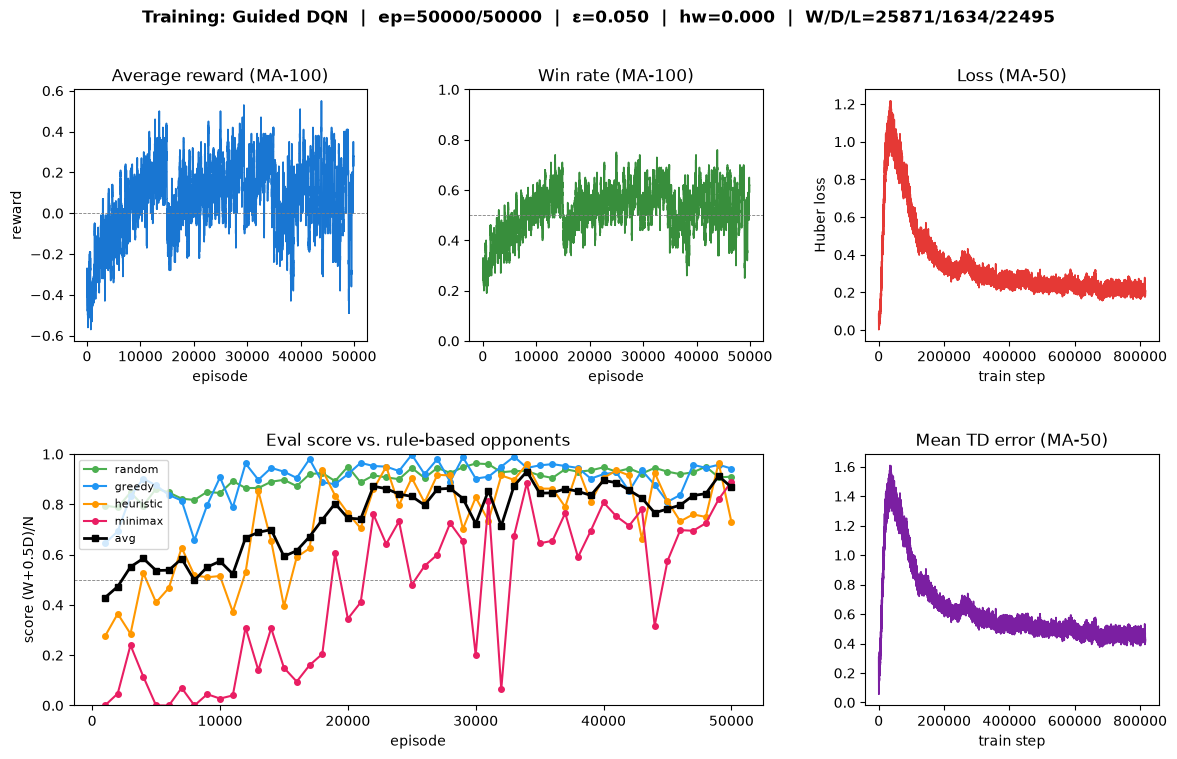

✓ Guided DQN saved → models/guided_dqn_50k.pth  |  W/D/L=25871/1634/22495

✓ Training of all agents completed.


In [7]:
# ── Run Training for All Four Agents ───────────────────────────
# Each agent trains sequentially; change order or comment out
# agents you don't want to train.

TRAINED_AGENTS = {}   # name → DQNAgent instance
TRAIN_HISTORY  = {}   # name → history dict

for agent_name, agent_cfg in AGENT_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  Training: {agent_name}")
    print(f"{'='*60}")
    agent, hist = train_agent_with_plot(agent_name, agent_cfg, TRAIN_CFG)
    TRAINED_AGENTS[agent_name] = agent
    TRAIN_HISTORY[agent_name]  = hist

print("\n✓ Training of all agents completed.")

## 4 — Individual Evaluation vs. Rule-Based Agents

100 games per combination (50× as player 1, 50× as player -1).

In [8]:
def evaluate_all_agents(trained_agents, board_size=BOARD_SIZE, n_games=100):
    """Returns a DataFrame-like dict with scores for each agent vs. each opponent."""
    results = {}
    for agent_name, agent in trained_agents.items():
        agent.q_net.eval()
        results[agent_name] = {}
        for opp_name, opp_cls in OPPONENT_CLASSES.items():
            res = evaluate_fair(agent_a=agent, agent_b_class=opp_cls,
                                board_size=board_size, n_games=n_games)
            results[agent_name][opp_name] = res
        agent.q_net.train()
    return results

EVAL_RESULTS = evaluate_all_agents(TRAINED_AGENTS)
print("Evaluation complete.")

Evaluation complete.


In [9]:
# ── Results Table ─────────────────────────────────────────────
opp_names   = list(OPPONENT_CLASSES.keys())
agent_names = list(TRAINED_AGENTS.keys())

print(f"{'Agent':<16}", end="")
for o in opp_names:
    print(f"  {o:>10}", end="")
print(f"  {'∅ score':>10}")
print("-" * (16 + 12 * len(opp_names) + 12))

for aname in agent_names:
    scores = [EVAL_RESULTS[aname][o]["score"] for o in opp_names]
    print(f"{aname:<16}", end="")
    for s in scores:
        print(f"  {s:>10.3f}", end="")
    print(f"  {np.mean(scores):>10.3f}")

Agent                 random      greedy   heuristic     minimax     ∅ score
----------------------------------------------------------------------------
Guided DQN             0.960       0.905       0.755       0.860       0.870


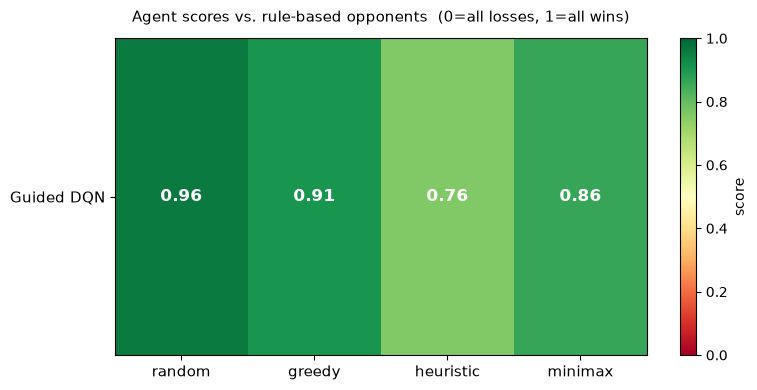

In [10]:
# ── Score Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
data = np.array([[EVAL_RESULTS[a][o]["score"] for o in opp_names]
                 for a in agent_names])

im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(opp_names)));   ax.set_xticklabels(opp_names,  fontsize=11)
ax.set_yticks(range(len(agent_names))); ax.set_yticklabels(agent_names, fontsize=11)
ax.set_title("Agent scores vs. rule-based opponents  (0=all losses, 1=all wins)",
             fontsize=11, pad=12)
plt.colorbar(im, ax=ax, label="score")

for i in range(len(agent_names)):
    for j in range(len(opp_names)):
        ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if data[i,j] < 0.4 or data[i,j] > 0.75 else "black")

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/eval_heatmap.png", dpi=120)
plt.show()

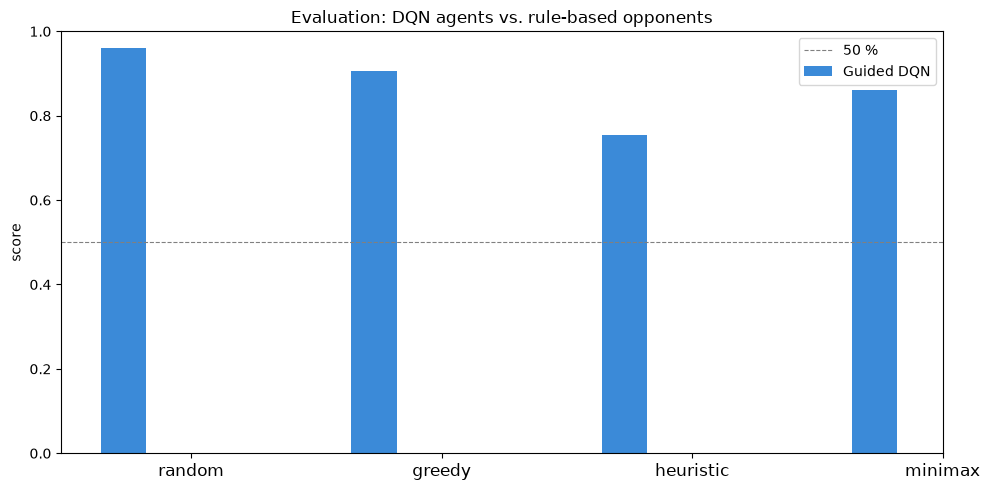

In [11]:
# ── Grouped Bar Chart ────────────────────────────────────────────
x      = np.arange(len(opp_names))
width  = 0.18
colors = ["#1976D2", "#388E3C", "#E53935", "#7B1FA2"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (aname, col) in enumerate(zip(agent_names, colors)):
    scores = [EVAL_RESULTS[aname][o]["score"] for o in opp_names]
    ax.bar(x + i * width - 1.5 * width, scores, width,
           label=aname, color=col, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(opp_names, fontsize=12)
ax.set_ylabel("score"); ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", label="50 %")
ax.set_title("Evaluation: DQN agents vs. rule-based opponents")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/eval_bar.png", dpi=120)
plt.show()

## 5 — Round-Robin Tournament (DQN Agents Against Each Other)

Each pair plays `N_TOURNAMENT_GAMES` games (half as player 1, half as -1).
Results matrix and final ranking are displayed.

In [12]:
N_TOURNAMENT_GAMES = 100   # games per pair (recommended ≥ 100)
BOARD_SIZE_T       = BOARD_SIZE

def play_match(agent_a, agent_b, board_size=BOARD_SIZE_T, n_games=N_TOURNAMENT_GAMES):
    """
    agent_a plays n_games/2 as player 1 and n_games/2 as player -1.
    Returns (a_wins, draws, b_wins, a_score).
    """
    a_wins = b_wins = draws = 0
    half   = n_games // 2

    for role_a in [1, -1]:          # agent_a alternates colors
        for _ in range(half):
            env = OthelloEnv(board_size=board_size)
            obs = env.reset()
            done = False
            while not done:
                if env.current_player == role_a:
                    action = agent_a.select_action(obs)
                else:
                    action = agent_b.select_action(obs)
                obs, _, done, info = env.step(action)
            w = info["winner"]
            if   w == role_a:  a_wins += 1
            elif w == -role_a: b_wins += 1
            else:              draws  += 1

    a_score = (a_wins + 0.5 * draws) / n_games
    return a_wins, draws, b_wins, a_score


def run_round_robin(trained_agents, n_games=N_TOURNAMENT_GAMES):
    """Returns score matrix and ranking."""
    names = list(trained_agents.keys())
    n     = len(names)
    score_matrix = np.zeros((n, n))

    for i, na in enumerate(names):
        for j, nb in enumerate(names):
            if i == j:
                score_matrix[i, j] = 0.5   # against itself = draw
                continue
            ag_a = trained_agents[na]
            ag_b = trained_agents[nb]
            ag_a.q_net.eval(); ag_b.q_net.eval()

            _, _, _, sc = play_match(ag_a, ag_b, n_games=n_games)
            score_matrix[i, j] = sc
            print(f"  {na:<15} vs {nb:<15} → score A = {sc:.3f}")

    return names, score_matrix

print(f"Running round-robin tournament ({N_TOURNAMENT_GAMES} games / pair) ...")
T_NAMES, T_MATRIX = run_round_robin(TRAINED_AGENTS)
print("\nTournament complete.")

Running round-robin tournament (100 games / pair) ...

Tournament complete.


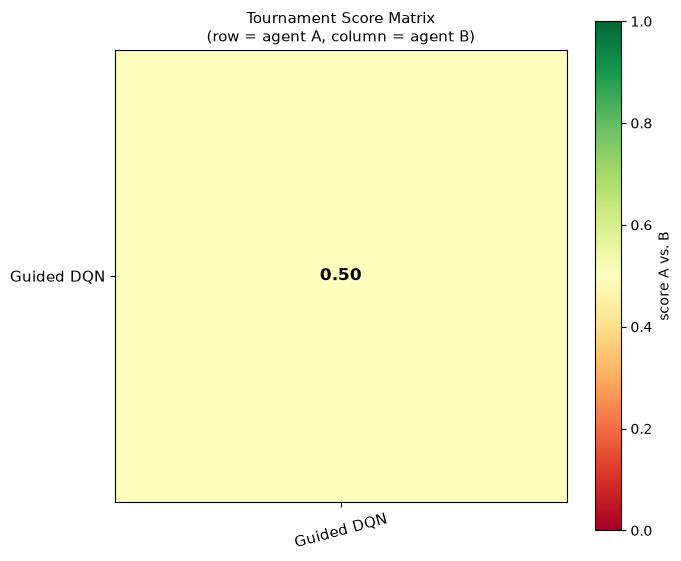

In [13]:
# ── Results Matrix ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(T_MATRIX, vmin=0, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(T_NAMES))); ax.set_xticklabels(T_NAMES, fontsize=11, rotation=15)
ax.set_yticks(range(len(T_NAMES))); ax.set_yticklabels(T_NAMES, fontsize=11)
ax.set_title(f"Tournament Score Matrix\n(row = agent A, column = agent B)", fontsize=11)
plt.colorbar(im, ax=ax, label="score A vs. B")

for i in range(len(T_NAMES)):
    for j in range(len(T_NAMES)):
        ax.text(j, i, f"{T_MATRIX[i,j]:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if T_MATRIX[i,j] < 0.35 or T_MATRIX[i,j] > 0.72 else "black")

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/tournament_matrix.png", dpi=120)
plt.show()

In [14]:
# ── Ranking by Average Score ────────────────────────────────
avg_scores = T_MATRIX.mean(axis=1)   # average across all opponents
ranking    = np.argsort(avg_scores)[::-1]

print(f"{'Ranking':<8} {'Agent':<16} {'Average Score':>16}")
print("-" * 42)
for rank, idx in enumerate(ranking, 1):
    print(f"  {rank:<6} {T_NAMES[idx]:<16} {avg_scores[idx]:>16.3f}")

Ranking  Agent               Average Score
------------------------------------------
  1      Guided DQN                  0.500


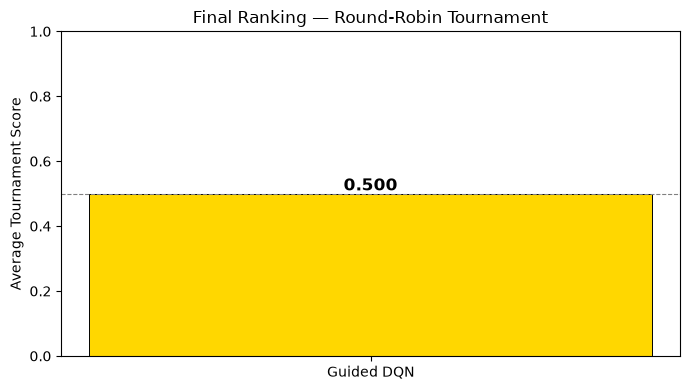

In [15]:
# ── Ranking Bar Chart ─────────────────────────────────────────
sorted_names  = [T_NAMES[i] for i in ranking]
sorted_scores = [avg_scores[i] for i in ranking]
colors_rank   = ["gold", "silver", "#cd7f32", "#90A4AE"][:len(sorted_names)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sorted_names, sorted_scores, color=colors_rank[::-1], edgecolor="black", linewidth=0.7)
ax.set_ylabel("Average Tournament Score")
ax.set_ylim(0, 1); ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Final Ranking — Round-Robin Tournament")
for bar, sc in zip(bars, sorted_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{sc:.3f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/tournament_ranking.png", dpi=120)
plt.show()

## 6 — Summary and Comparative Training Curves

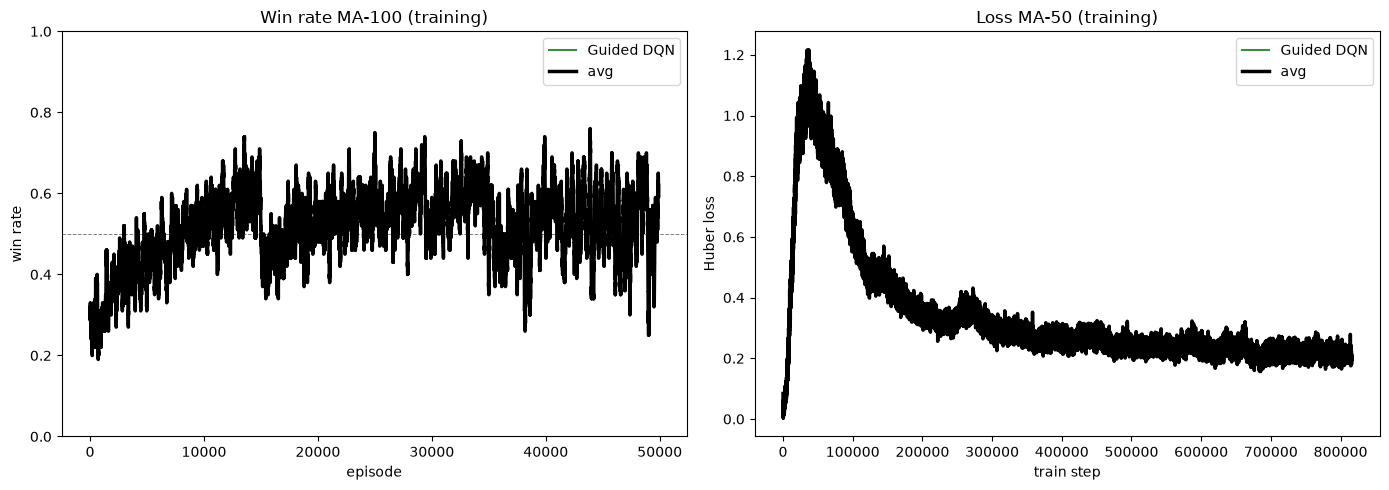

In [16]:
# ── Compare Training Win-Rate Curves ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"DQN": "#1976D2", "Guided DQN": "#388E3C",
          "PER DQN": "#E53935", "Guided PER": "#7B1FA2"}

# --- Win rate ---
win_curves = {}
for aname, hist in TRAIN_HISTORY.items():
    col = colors.get(aname, "gray")
    if len(hist["wins"]) >= 100:
        ma = moving_average(hist["wins"], 100)
        win_curves[aname] = ma
        axes[0].plot(ma, label=aname, color=col, linewidth=1.5)

# Black average across all agents (aligned to shortest curve)
if win_curves:
    min_len = min(len(v) for v in win_curves.values())
    if min_len > 0:
        avg_win = np.mean([v[:min_len] for v in win_curves.values()], axis=0)
        axes[0].plot(avg_win, color="black", linewidth=2.5, linestyle="-",
                     label="avg", zorder=5)

axes[0].set_title("Win rate MA-100 (training)", fontsize=12)
axes[0].set_xlabel("episode"); axes[0].set_ylabel("win rate")
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=10)
axes[0].axhline(0.5, color="gray", linewidth=0.7, linestyle="--")

# --- Loss ---
loss_curves = {}
for aname, hist in TRAIN_HISTORY.items():
    col = colors.get(aname, "gray")
    if len(hist["losses"]) >= 50:
        ma = moving_average(hist["losses"], 50)
        loss_curves[aname] = ma
        axes[1].plot(ma, label=aname, color=col, linewidth=1.5)

if loss_curves:
    min_len = min(len(v) for v in loss_curves.values())
    if min_len > 0:
        avg_loss = np.mean([v[:min_len] for v in loss_curves.values()], axis=0)
        axes[1].plot(avg_loss, color="black", linewidth=2.5, linestyle="-",
                     label="avg", zorder=5)

axes[1].set_title("Loss MA-50 (training)", fontsize=12)
axes[1].set_xlabel("train step"); axes[1].set_ylabel("Huber loss")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/training_curves.png", dpi=120)
plt.show()


  Guided DQN       final score vs. minimax = 0.890


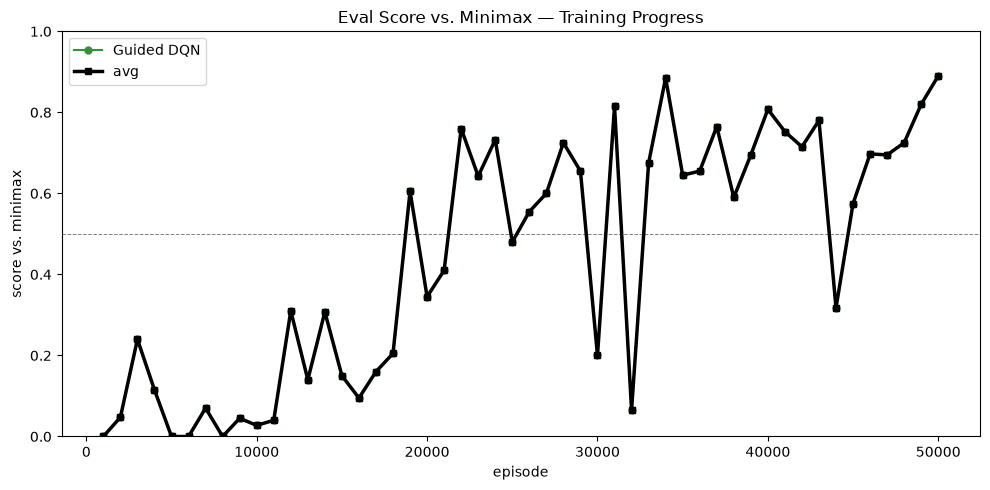

In [17]:
# ── Eval Score Over Time (vs. Minimax) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

minimax_curves = {}
for aname, hist in TRAIN_HISTORY.items():
    col = colors.get(aname, "gray")
    eps = hist["eval_episodes"]
    if eps:
        scores = hist["eval_scores"]["minimax"]
        minimax_curves[aname] = (eps, scores)
        ax.plot(eps, scores,
                marker="o", markersize=5, label=aname, color=col)
        print(f"  {aname:<15}  final score vs. minimax = {scores[-1]:.3f}")

# Black average across all agents (aligned to common episode ticks)
if minimax_curves:
    common_eps = None
    for eps, _ in minimax_curves.values():
        common_eps = eps if common_eps is None else eps
        common_eps = [e for e in common_eps if e in eps]
    if common_eps:
        avg_vals = []
        for e in common_eps:
            vals = []
            for eps, scores in minimax_curves.values():
                if e in eps:
                    idx = eps.index(e)
                    vals.append(scores[idx])
            avg_vals.append(np.mean(vals))
        ax.plot(common_eps, avg_vals,
                color="black", linewidth=2.5, linestyle="-",
                marker="s", markersize=5, label="avg", zorder=5)

ax.set_title("Eval Score vs. Minimax — Training Progress", fontsize=12)
ax.set_xlabel("episode"); ax.set_ylabel("score vs. minimax")
ax.set_ylim(0, 1); ax.legend(fontsize=10)
ax.axhline(0.5, color="gray", linewidth=0.7, linestyle="--")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/eval_vs_minimax.png", dpi=120)
plt.show()


In [18]:
# ── Final Summary ─────────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)

print("\nAverage score vs. rule-based (eval):")
for aname in agent_names:
    scores = [EVAL_RESULTS[aname][o]["score"] for o in opp_names]
    print(f"  {aname:<16}  avg={np.mean(scores):.3f}  "
          + "  ".join(f"{o}={EVAL_RESULTS[aname][o]['score']:.2f}" for o in opp_names))

print("\nTournament Ranking (round-robin):")
for rank, idx in enumerate(ranking, 1):
    print(f"  {rank}. {T_NAMES[idx]:<16}  avg_score={avg_scores[idx]:.3f}")

print("\nSaved Files:")
for _, cfg in AGENT_CONFIGS.items():
    path = cfg["model_path"]
    if os.path.exists(path):
        size = os.path.getsize(path) // 1024
        print(f"  {path}  ({size} kB)")

for fname in ["eval_heatmap.png","eval_bar.png",
              "tournament_matrix.png","tournament_ranking.png",
              "training_curves.png","eval_vs_minimax.png"]:
    fpath = f"{MODELS_DIR}/{fname}"
    if os.path.exists(fpath):
        print(f"  {fpath}")


  FINAL SUMMARY

Average score vs. rule-based (eval):
  Guided DQN        avg=0.870  random=0.96  greedy=0.91  heuristic=0.76  minimax=0.86

Tournament Ranking (round-robin):
  1. Guided DQN        avg_score=0.500

Saved Files:
  models/guided_dqn_50k.pth  (5284 kB)
  models/eval_heatmap.png
  models/eval_bar.png
  models/tournament_matrix.png
  models/tournament_ranking.png
  models/training_curves.png
  models/eval_vs_minimax.png


## 7 — Multi-Agent Training (Optional)

Alternative to section 3 — all agents train simultaneously,
each episode a learner and opponent are randomly selected.

In [19]:
result = train_multi_agent(
    board_size=BOARD_SIZE,
    num_episodes=5000,
    model_dir=f"{MODELS_DIR}/multi",
    print_every=500,
)



trained_agents = result["agents"]
stats = result["stats"]

print("\nStatistics after multi-agent training:")
for name, s in stats.items():
    print(f"{name:<14} W/D/L = {s['wins']}/{s['draws']}/{s['losses']}")

[   500/5000] learner=per          opp=guided     ε=0.368 | reward=-1.0 | avg_r_100=-0.550
[  1000/5000] learner=dqn          opp=guided     ε=0.135 | reward=-1.0 | avg_r_100=-0.620
[  1500/5000] learner=guided       opp=per        ε=0.050 | reward=-1.0 | avg_r_100=0.220
[  2000/5000] learner=guided       opp=dqn        ε=0.050 | reward=1.0 | avg_r_100=0.270
[  2500/5000] learner=dqn          opp=guided_per ε=0.050 | reward=-1.0 | avg_r_100=-0.260
[  3000/5000] learner=guided_per   opp=guided     ε=0.050 | reward=-1.0 | avg_r_100=0.190
[  3500/5000] learner=guided       opp=guided_per ε=0.050 | reward=1.0 | avg_r_100=0.300
[  4000/5000] learner=guided       opp=minimax    ε=0.050 | reward=-1.0 | avg_r_100=0.230
[  4500/5000] learner=dqn          opp=minimax    ε=0.050 | reward=-1.0 | avg_r_100=-0.280
[  5000/5000] learner=guided       opp=greedy     ε=0.050 | reward=-1.0 | avg_r_100=0.140
Saved dqn → models/multi/dqn.pth
Saved guided → models/multi/guided.pth
Saved per → models/multi/p

---
## 7 — Play Against Agent (Jupyter Widget)

Interactive game directly in the notebook. Click on a square or use the Pass button.
Green dots mark your legal moves.

**Settings before running:**
- `PLAY_AGENT_NAME` — select an agent (or `"minimax"`, `"random"`, etc.)
- `HUMAN_COLOR` — `1` = you play as X and start, `-1` = you play as O

In [20]:
# ── Game Configuration ────────────────────────────────────────────────
PLAY_AGENT_NAME = "DQN"     # key from TRAINED_AGENTS, or "random"/"greedy"/"heuristic"/"minimax"
HUMAN_COLOR     = 1         # 1 = X (starts), -1 = O
PLAY_BOARD_SIZE = BOARD_SIZE

# If you want to play against a rule-based agent (without training):
# PLAY_AGENT_NAME = "minimax"

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import copy, time

# ── Prepare Agent ────────────────────────────────────────────────
if PLAY_AGENT_NAME in TRAINED_AGENTS:
    _play_agent = TRAINED_AGENTS[PLAY_AGENT_NAME]
    _play_agent.q_net.eval()
    print(f"You are playing against: {PLAY_AGENT_NAME} (DQN)")
else:
    _play_agent = OPPONENT_CLASSES[PLAY_AGENT_NAME](PLAY_BOARD_SIZE)
    print(f"You are playing against: {PLAY_AGENT_NAME} (rule-based)")

# ── Constants and Colors ─────────────────────────────────────────
_HUMAN_SYM = "X" if HUMAN_COLOR == 1 else "O"
_AGENT_SYM = "O" if HUMAN_COLOR == 1 else "X"

_COLOR_MAP = {
     1: "#27AE60",   # green — X
    -1: "#E74C3C",   # red — O
     0: "#ECF0F1",   # light — empty
}
_LEGAL_COLOR  = "#85C1E9"   # light blue — legal moves
_BUTTON_STYLE = "width:52px;height:52px;font-size:18px;font-weight:bold;border-radius:6px;margin:2px;"

# ── Game State ─────────────────────────────────────────────────
_game_env  = OthelloEnv(board_size=PLAY_BOARD_SIZE)
_game_obs  = _game_env.reset()
_game_done = False

# ── UI Elements ─────────────────────────────────────────────────
_status_label = widgets.HTML(value="")
_score_label  = widgets.HTML(value="")
_pass_btn     = widgets.Button(description="Pass ⏩",
                               button_style="warning",
                               layout=widgets.Layout(width="110px", height="40px"))
_new_btn      = widgets.Button(description="New Game 🔄",
                               button_style="info",
                               layout=widgets.Layout(width="130px", height="40px"))
_history_out  = widgets.Output(layout=widgets.Layout(max_height="160px", overflow_y="auto"))

# Grid of buttons (board_size × board_size)
_btn_grid = [
    [widgets.Button(layout=widgets.Layout(width="52px", height="52px", margin="2px"))
     for _ in range(PLAY_BOARD_SIZE)]
    for _ in range(PLAY_BOARD_SIZE)
]

# ── Helper Functions ────────────────────────────────────────────
def _get_legal_cells(env):
    legal  = env.get_legal_actions(env.current_player)
    pass_a = env.pass_action
    return {divmod(a, env.board_size) for a in legal if a != pass_a}, (legal == [pass_a])

def _update_board_ui():
    env = _game_env
    n   = env.board_size
    is_human_turn = (env.current_player == HUMAN_COLOR)
    legal_cells, only_pass = _get_legal_cells(env)

    for r in range(n):
        for c in range(n):
            btn = _btn_grid[r][c]
            val = int(env.board_abs[r, c])
            if val == 1:
                label = "X"; bg = _COLOR_MAP[1]; color = "white"
            elif val == -1:
                label = "O"; bg = _COLOR_MAP[-1]; color = "white"
            elif is_human_turn and (r, c) in legal_cells:
                label = "·"; bg = _LEGAL_COLOR; color = "#2C3E50"
            else:
                label = ""; bg = _COLOR_MAP[0]; color = "black"

            btn.description = label
            btn.disabled    = not (is_human_turn and (r, c) in legal_cells)
            btn.style.button_color = bg
            btn.style.font_weight  = "bold"

    # Pass button
    _pass_btn.disabled = not (is_human_turn and only_pass)

    # Score
    x_cnt = int((env.board_abs == 1).sum())
    o_cnt = int((env.board_abs == -1).sum())
    _score_label.value = (
        f"<span style='font-size:14px'>"
        f"<b style='color:#27AE60'>X: {x_cnt}</b> &nbsp;|&nbsp; "
        f"<b style='color:#E74C3C'>O: {o_cnt}</b> &nbsp;|&nbsp; "
        f"Turn: {env.turn_count}"
        f"</span>"
    )

    # Status
    if _game_done:
        return
    who = f"<b style='color:#27AE60'>You ({_HUMAN_SYM})</b>" if is_human_turn \
          else f"<b style='color:#E74C3C'>Agent ({_AGENT_SYM})</b>"
    _status_label.value = (
        f"<span style='font-size:14px'>Turn: {who}"
        + (" &nbsp;⚠️ <i>pass only</i>" if only_pass and is_human_turn else "")
        + "</span>"
    )

def _log(msg: str):
    with _history_out:
        print(msg)

def _finish_game():
    global _game_done
    _game_done = True
    info = _game_env.get_observation()   # for disc count
    x_cnt = int((_game_env.board_abs == 1).sum())
    o_cnt = int((_game_env.board_abs == -1).sum())
    winner = _game_env.get_winner() if hasattr(_game_env, "get_winner") else None

    # Disable all buttons
    for r in range(PLAY_BOARD_SIZE):
        for c in range(PLAY_BOARD_SIZE):
            _btn_grid[r][c].disabled = True
    _pass_btn.disabled = True

    if winner == HUMAN_COLOR:
        msg = f"🎉 <b style='color:#27AE60;font-size:16px'>You won! ({x_cnt}–{o_cnt})</b>"
    elif winner == 0:
        msg = f"🤝 <b style='font-size:16px'>Draw! ({x_cnt}–{o_cnt})</b>"
    else:
        msg = f"🤖 <b style='color:#E74C3C;font-size:16px'>Agent won. ({x_cnt}–{o_cnt})</b>"
    _status_label.value = msg
    _log(f"[end] {msg.replace('<b','').replace('</b>','').replace(\"style='color:#27AE60;font-size:16px'\",'').replace(\"style='color:#E74C3C;font-size:16px'\",'').replace(\"style='font-size:16px'\",'')}\")")

def _agent_move():
    """Performs agent move (no exploration)."""
    obs = _game_env.get_observation()
    if hasattr(_play_agent, "select_action"):
        try:
            action = _play_agent.select_action(obs, epsilon=0.0)
        except TypeError:
            action = _play_agent.select_action(obs)
    else:
        action = _play_agent.select_action(obs)

    n = _game_env.board_size
    if action == _game_env.pass_action:
        _log(f"Agent ({_AGENT_SYM}): pass")
    else:
        r, c = divmod(action, n)
        _log(f"Agent ({_AGENT_SYM}): ({r},{c})")

    _, _, done, _ = _game_env.step(action)
    return done

def _human_move(action: int):
    """Processes human move and agent response if needed."""
    global _game_done
    if _game_done:
        return

    n = _game_env.board_size
    if action == _game_env.pass_action:
        _log(f"You ({_HUMAN_SYM}): pass")
    else:
        r, c = divmod(action, n)
        _log(f"You ({_HUMAN_SYM}): ({r},{c})")

    _, _, done, _ = _game_env.step(action)
    _update_board_ui()

    if done:
        _finish_game()
        return

    # Agent responds
    _status_label.value = "<span style='font-size:14px'>Agent is thinking...</span>"
    done = _agent_move()
    _update_board_ui()

    if done:
        _finish_game()
    elif _game_env.current_player != HUMAN_COLOR:
        # Agent must pass (should not happen, but just in case)
        done = _agent_move()
        _update_board_ui()
        if done:
            _finish_game()

# ── Button Handlers ─────────────────────────────────────────────
def _on_cell_click(r, c):
    def handler(btn):
        action = r * PLAY_BOARD_SIZE + c
        _human_move(action)
    return handler

for _r in range(PLAY_BOARD_SIZE):
    for _c in range(PLAY_BOARD_SIZE):
        _btn_grid[_r][_c].on_click(_on_cell_click(_r, _c))

def _on_pass(btn):
    _human_move(_game_env.pass_action)

def _on_new_game(btn):
    global _game_obs, _game_done
    _game_env.reset()
    _game_done = False
    with _history_out:
        clear_output()
    _log("── New Game ──")

    # If agent starts (human_color == -1), perform first move
    if _game_env.current_player != HUMAN_COLOR:
        done = _agent_move()
        if done:
            _update_board_ui()
            _finish_game()
            return
    _update_board_ui()

_pass_btn.on_click(_on_pass)
_new_btn.on_click(_on_new_game)

# ── Layout Assembly ─────────────────────────────────────────────
_grid_rows  = [widgets.HBox([_btn_grid[r][c] for c in range(PLAY_BOARD_SIZE)])
               for r in range(PLAY_BOARD_SIZE)]
_board_box  = widgets.VBox(_grid_rows)
_ctrl_box   = widgets.HBox([_pass_btn, _new_btn],
                            layout=widgets.Layout(margin="8px 0"))
_info_box   = widgets.VBox([_status_label, _score_label])
_right_box  = widgets.VBox([_info_box, _ctrl_box, _history_out],
                            layout=widgets.Layout(margin="0 0 0 24px", min_width="200px"))
_main_box   = widgets.HBox([_board_box, _right_box])

# ── Launch: if agent plays as X, it starts ─────────────────────
if _game_env.current_player != HUMAN_COLOR:
    _agent_move()

_update_board_ui()
_log("── Game Begins ──")
display(_main_box)

SyntaxError: f-string expression part cannot include a backslash (684271037.py, line 129)